In [1]:
from medlat import available_models, get_model, MODEL_REGISTRY
from medlat.diffusion import create_gaussian_diffusion

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST, CIFAR100, CIFAR10
from medmnist import PathMNIST, BreastMNIST
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F
from dataset import MergedMedMNIST
from medmnist import INFO
import glob
import os


### Prep Dataset ###
tensor_transforms = transforms.Compose(
    [
        transforms.Resize((224,224)),
        transforms.ToTensor(),
    ]
)

train_set = MergedMedMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="train", transform=tensor_transforms, download=False, size=224, ds_names=["breastmnist", "retinamnist"])
test_set = MergedMedMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="test", transform=tensor_transforms, download=False, size=224, ds_names=["breastmnist", "retinamnist"])

# train_set = BreastMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="train", transform=tensor_transforms, download=False, as_rgb=True, size=224)
# test_set = BreastMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="test", transform=tensor_transforms, download=False, as_rgb=True, size=224)

# train_set = CIFAR10(root=".", train=True, transform=tensor_transforms, download=True)
# test_set = CIFAR10(root=".", train=False, transform=tensor_transforms, download=True)

### Set Device ###
device = "cuda" if torch.cuda.is_available() else "cpu"

attention mode is flash
Loading dataset: breastmnist
Loading dataset: retinamnist
Loading dataset: breastmnist
Loading dataset: retinamnist


In [2]:
def train(model,
          train_set,
          test_set,
          batch_size,
          num_epochs,
          evaluation_iterations,
          break_step):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)

    trainloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=8)
    testloader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=8)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    
    diffusion = create_gaussian_diffusion(
        steps= 1000,
        learn_sigma= True,
        sigma_small= False,
        noise_schedule= "linear",
        use_kl= False,
        predict_xstart= False,
        rescale_timesteps= False,
        rescale_learned_sigmas= False,
        timestep_respacing= ""
    )

    diffusion_eval = create_gaussian_diffusion(
        steps= 1000,
        learn_sigma= True,
        sigma_small= False,
        noise_schedule= "linear",
        use_kl= False,
        predict_xstart= False,
        rescale_timesteps= False,
        rescale_learned_sigmas= False,
        timestep_respacing= "64"
    )

    train_losses = []
    evaluation_losses = []

    steps_per_epoch = len(trainloader)
    total_steps = steps_per_epoch * num_epochs
    step_counter = 0
    train_loss_running = []
    evaluation_loss_running = []

    with tqdm(total=num_epochs, desc="Epochs") as epoch_bar:
        for epoch in range(num_epochs):
            model.train()
            with tqdm(total=steps_per_epoch, desc=f"Epoch {epoch+1}/{num_epochs} | loss: N/A", leave=False) as pbar:
                for batch in trainloader:
                    
                    images, labels, dataset_ids = batch["image"], batch["label"], batch["dataset_id"]
                    images, labels, dataset_ids = images.to(device), labels.to(device).squeeze(1), dataset_ids.to(device)
                    print(labels.shape, dataset_ids.shape)
                    cond = dict(y=labels, dataset_id=dataset_ids)

                    t = torch.randint(0, diffusion.num_timesteps, (images.shape[0],), device=images.device)
                    z = model.vae_encode(images)
                    
                    terms = diffusion.training_losses(model, z, t, model_kwargs=cond)
                    loss = terms["loss"].mean()

                    # Update tqdm description with current loss value
                    pbar.set_description(f"Epoch {epoch+1}/{num_epochs} | loss: {loss.item():.4f}")

                    train_loss_running.append(loss.item())

                    loss.backward()
                    optimizer.step()
                    optimizer.zero_grad()

                    step_counter += 1
                    pbar.update(1)

                    if step_counter % break_step == 0:
                        break

                    # Evaluate every evaluation_iterations global step
                    if step_counter % evaluation_iterations == 0:
                        model.eval()
                        evaluation_loss_running.clear()
                        example_shown = False
                        with torch.no_grad():
                            cond = dict(y=labels, cfg_scale=2.0)
                            sample = diffusion_eval.p_sample_loop(model.generator.forward_with_cfg, z.shape, clip_denoised=False, progress=True, model_kwargs=cond, temperature=1.0, device=device)
                            out = model.vae_decode(sample)
                        # INSERT_YOUR_CODE
                        import matplotlib.pyplot as plt

                        # Assume 'out' has shape (batch, channels, height, width) or (batch, height, width)
                        to_show = out[0].detach().cpu().numpy()
                        if to_show.ndim == 3 and to_show.shape[0] in [1, 3]:
                            # (C,H,W) format, move channel last if necessary
                            to_show = np.transpose(to_show, (1, 2, 0))
                        elif to_show.ndim == 2:
                            pass  # Already H x W

                        # Clamp to [0,1] for display
                        plt.figure()
                        plt.imshow(np.clip(to_show, 0, 1), cmap=None if to_show.ndim == 3 else "gray")
                        plt.axis('off')
                        plt.show()


                        train_loss_val = np.mean(train_loss_running) if train_loss_running else 0.0
                        evaluation_loss_val = np.mean(evaluation_loss_running) if evaluation_loss_running else 0.0
                        train_losses.append(train_loss_val)
                        evaluation_losses.append(evaluation_loss_val)
                        train_loss_running = []
                        model.train()
            if step_counter % break_step == 0:
                break
            epoch_bar.update(1)
            

    print("Final Training Loss", train_losses[-1] if train_losses else "No log")
    print("Final Evaluation Loss", evaluation_losses[-1] if evaluation_losses else "No log")

    return model, train_losses, evaluation_losses

In [3]:
def find_latest_checkpoint(base_output_dir):
    checkpoints = glob.glob(os.path.join(base_output_dir, "train/models/ckpt.*.pt"))
    if not checkpoints:
        print("No checkpoints found in the output directory: ", base_output_dir + "/train/models")
        return None
    # Filter out the best checkpoint and get the latest numbered checkpoint
    checkpoints = [(int(ckpt.split('ckpt.')[1].split('.pt')[0]), ckpt) 
                  for ckpt in checkpoints if 'ckpt.best.pt' not in ckpt]
    print("Found the following checkpoints: ", checkpoints)
    return max(checkpoints, key=lambda x: x[0])[1] if checkpoints else None

('adm.classifier.128c', 'adm.classifier.256c', 'adm.classifier.512c', 'adm.classifier.64c', 'adm.diffusion.128c', 'adm.diffusion.128u', 'adm.diffusion.256c', 'adm.diffusion.256u', 'adm.diffusion.512c', 'adm.diffusion.512u', 'adm.diffusion.64c', 'adm.diffusion.64u', 'continuous.aekl.f16_d16', 'continuous.aekl.f16_d32', 'continuous.aekl.f16_d64', 'continuous.aekl.f16_d8', 'continuous.aekl.f32_d64', 'continuous.aekl.f4_d16', 'continuous.aekl.f4_d3', 'continuous.aekl.f4_d32', 'continuous.aekl.f4_d8', 'continuous.aekl.f8_d16', 'continuous.aekl.f8_d32', 'continuous.aekl.f8_d4', 'continuous.aekl.f8_d8', 'continuous.maisi.f4_d3', 'continuous.medvae.f8_d16', 'continuous.medvae.f8_d32', 'continuous.vavae.f16_d16_dinov2', 'continuous.vavae.f16_d16_mae', 'continuous.vavae.f16_d32_dinov2', 'continuous.vavae.f16_d32_mae', 'continuous.vavae.f16_d64_dinov2', 'continuous.vavae.f16_d64_mae', 'continuous.vavae.f8_d16_dinov2', 'continuous.vavae.f8_d32_dinov2', 'discrete.bsq.f16_d10_b10', 'discrete.bsq.f16

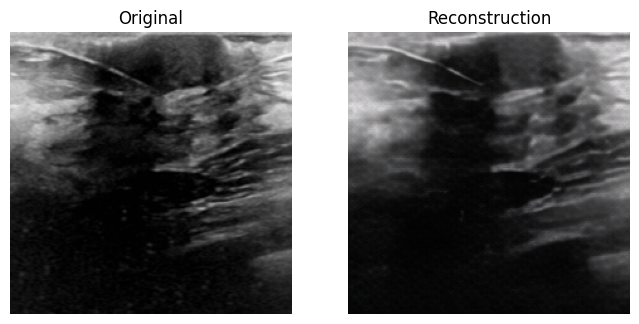

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100 | loss: N/A:   0%|          | 0/51 [00:00<?, ?it/s]

torch.Size([32]) torch.Size([32])
torch.Size([32]) torch.Size([32])
torch.Size([32]) torch.Size([32])
torch.Size([32]) torch.Size([32])
torch.Size([32]) torch.Size([32])


  0%|          | 0/64 [00:00<?, ?it/s]

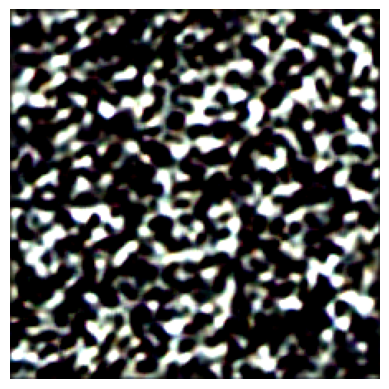

torch.Size([32]) torch.Size([32])
Final Training Loss 0.9936451554298401
Final Evaluation Loss 0.0
training discrete.rqvae.f16_d8_e16384
Found the following checkpoints:  [(1, '/vol/miltank/users/bubeckn/medlat_outputs/medlat/discrete.rqvae.f16_d8_e16384/train/models/ckpt.1.pt')]
Working with z of shape (1, 8, 14, 14) = 1568 dimensions.
Loading pre-trained VQModel
Missing keys:
[]
Unexpected keys:
[]
Restored from /vol/miltank/users/bubeckn/medlat_outputs/medlat/discrete.rqvae.f16_d8_e16384/train/models/ckpt.1.pt
16
img_size: (224, 224), vae_stride: 16
img_size: (14, 14), patch_size: (2, 2)
generator_type: non-autoregressive, first_stage_type: discrete
Number of parameters in generator: 174037312
encoded to prequant
decoding from prequant


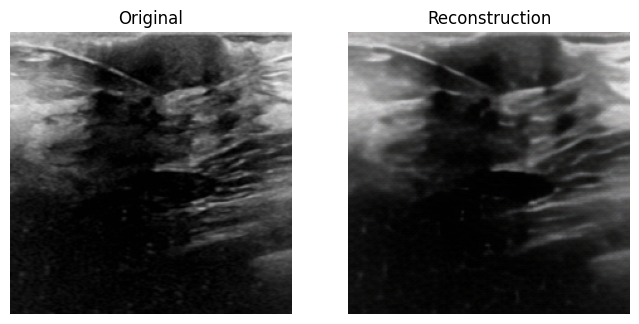

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100 | loss: N/A:   0%|          | 0/51 [00:00<?, ?it/s]

torch.Size([32]) torch.Size([32])
encoded to prequant
torch.Size([32]) torch.Size([32])
encoded to prequant
torch.Size([32]) torch.Size([32])
encoded to prequant
torch.Size([32]) torch.Size([32])
encoded to prequant
torch.Size([32]) torch.Size([32])
encoded to prequant


  0%|          | 0/64 [00:00<?, ?it/s]

decoding from prequant


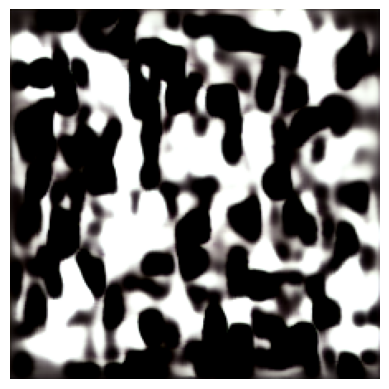

torch.Size([32]) torch.Size([32])
encoded to prequant
Final Training Loss 0.9943514943122864
Final Evaluation Loss 0.0


In [4]:
all_models = available_models()
print(all_models)
from medlat.modules.wrapper import GenWrapper

model_list=[
"continuous.aekl.f4_d3",
# "continuous.aekl.f8_d4", "continuous.aekl.f16_d8",
# "continuous.aekl.f4_d8", "continuous.aekl.f4_d16", "continuous.aekl.f4_d32",
# "continuous.aekl.f8_d8", "continuous.aekl.f8_d16", "continuous.aekl.f8_d32",
# "continuous.aekl.f16_d16", "continuous.aekl.f16_d32", "continuous.aekl.f16_d64",
# "continuous.medvae.f8_d16", "continuous.medvae.f8_d32", "continuous.vavae.f8_d16_dinov2", "continuous.vavae.f8_d32_dinov2",
# "discrete.lfq.f4_d10_b10", "discrete.lfq.f8_d14_b14", "discrete.lfq.f16_d18_b18",
# "discrete.bsq.f4_d10_b10", "discrete.bsq.f8_d14_b14", "discrete.bsq.f16_d18_b18",
# "discrete.simple_qinco.f16_d8_e16384", "discrete.simple_qinco.f4_d3_e8192", "discrete.simple_qinco.f8_d4_e16384",
# "discrete.simvq.f16_d8_e16384", "discrete.simvq.f4_d3_e8192", "discrete.simvq.f8_d4_e16384",
# "discrete.vq.f16_d8_e16384", "discrete.vq.f4_d3_e8192", "discrete.vq.f8_d4_e16384",
"discrete.rqvae.f16_d8_e16384",
# "discrete.rqvae.f4_d3_e8192", "discrete.rqvae.f8_d4_e16384",
]

for model_name in model_list:

    print(f"training {model_name}")
    base_output_dir = "/vol/miltank/users/bubeckn/medlat_outputs/medlat"
    latest_checkpoint = find_latest_checkpoint(base_output_dir + "/" + model_name)
    
    tokenizer = get_model(model_name, img_size=224, ckpt_path=latest_checkpoint)
    print(tokenizer.vae_stride)
    generator = get_model("dit.b_2", img_size=224, vae_stride=tokenizer.vae_stride, in_channels=tokenizer.embed_dim)
    wrapper = GenWrapper(generator, tokenizer)

    # INSERT_YOUR_CODE
    num_params = sum(p.numel() for p in generator.parameters())
    print(f"Number of parameters in generator: {num_params}")

    # INSERT_YOUR_CODE
    test_img = test_set[0]["image"]
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Prepare the image for model
    img_batch = test_img.unsqueeze(0).to(device)
    wrapper.to(device)
    z = wrapper.vae_encode(img_batch)
    recon = wrapper.vae_decode(z)[0].detach().cpu().numpy()

    # Original image
    orig = test_img.detach().cpu().numpy()
    if orig.ndim == 3 and orig.shape[0] in [1, 3]:
        orig = np.transpose(orig, (1,2,0))
    # Reconstructed image
    if recon.ndim == 3 and recon.shape[0] in [1,3]:
        recon = np.transpose(recon, (1,2,0))

    # Show side-by-side
    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(1, 2, figsize=(8,4))
    axs[0].imshow(np.clip(orig, 0, 1), cmap=None if orig.ndim==3 else "gray")
    axs[0].set_title("Original")
    axs[0].axis('off')
    axs[1].imshow(np.clip(recon, 0, 1), cmap=None if recon.ndim==3 else "gray")
    axs[1].set_title("Reconstruction")
    axs[1].axis('off')
    plt.show()


    linear_ae, train_losses, evaluation_losses = train(wrapper,
                                                        train_set=train_set,
                                                        test_set=test_set,
                                                        batch_size=32,
                                                        num_epochs=100,
                                                        evaluation_iterations=5,
                                                        break_step=6)

In [5]:
generated_index = 150
image, label = test_set[generated_index]

# Add batch dimension, move to device
image = image.unsqueeze(0).to(device)

# Forward pass
recon, _ = f4(image)

# Move to CPU, remove batch dim → shape: (C, H, W)
recon = recon.cpu().detach().squeeze()

# Convert to H×W×C (RGB) or H×W (grayscale)
if recon.ndim == 3:                 # C,H,W
    if recon.shape[0] == 1:         # grayscale
        recon = recon.squeeze(0)    # → H,W
        cmap = "gray"
    else:                           # RGB
        recon = recon.permute(1, 2, 0).numpy()
        cmap = None
else:
    cmap = "gray"

plt.imshow(recon, cmap=cmap)
plt.title("RVQVAE")
plt.axis("off")
plt.show()

ValueError: too many values to unpack (expected 2)